3 8
6 2
9 9
8 10
1 16
1 15
0 11
5 8
9 12
3 12
6 10
5 11
9 9
7 5
3 6
2 7
4 12
8 10
7 4
6 9
6 1
2 5
6 4
4 8
1 16
7 3
7 6
2 5
0 14
0 13
9 6
6 4
3 8
0 15
2 6
2 7
3 11
2 6
3 15
3 5
7 12
7 9
1 12
2 6
5 10
3 7
2 4
3 6
8 6
9 9
2 7
8 5
3 9
5 15
7 6
4 10
0 13
0 14
5 17
9 7
8 8
1 12
6 4
4 13
5 11
2 7
7 6
4 13
1 9
0 17
8 9
7 3
8 10
3 8
4 10
9 11
2 7
5 13
1 11
1 10
9 8
1 11
5 11
8 7
8 9
0 11
0 15
0 11
2 6
6 2
5 11
5 14
4 8
1 17
5 7
8 8
1 14
0 16
0 20
3 9
4 8
3 7
8 6
1 10
5 11
7 6
9 7
5 7
9 8
5 9
6 6
4 6
6 5
6 3
0 10
7 4
7 9
7 3
1 9
7 7
0 16
7 4
6 2
8 13
4 10
9 14
3 10
1 8
2 4
8 11
3 11
8 8
5 6
4 15
8 13
3 11
3 9
1 16
0 11
0 11
2 10
0 13
0 21
3 5
0 15
0 14
9 10
4 7
6 7
9 14
3 10
9 11
8 14
8 12
2 3
9 9
8 6
5 11
4 12
2 10
8 7
1 16
9 14
1 12
0 13
2 11
9 11
9 9
5 14
2 10
7 7
6 6
3 12
8 9
7 11
1 11
3 7
9 10
2 11
6 7
6 2
9 7
1 10
5 10
5 10
4 5
7 8
8 15
9 8
6 4
5 16
8 16
0 11
1 13
9 11
2 9
5 11
8 10
3 7
6 6
0 14
7 9
9 12
3 9
7 6
0 15
2 7
3 9
1 13
6 6
8 13
6 6
0 16
7 4
0 15
0 15
1 16
5 14
5 12
4 6
3 6
4 7
4

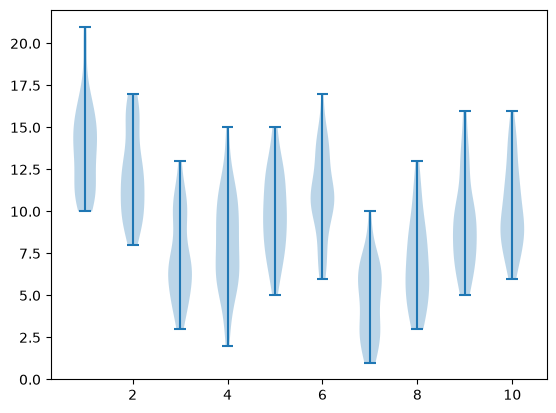

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Thu Nov 19 10:48:05 2020

@authors: berar && Oumar
"""

import numpy as np
import matplotlib.pyplot as plt


class Bandit:
    
    def __init__(self, K=10):
        self.K=K
        np.random.seed(5)
        self.variance = np.random.randint(-1,2,size=self.K)
        self.biais = np.random.poisson(3,self.K)
        while sum(self.biais == self.biais.max()) != 1 :
            self.biais = np.random.poisson(3,K)
  
    def get_arm(self,k):   
        reward  = np.random.poisson(6+self.variance[k]) + self.biais[k]  
        return reward


if __name__ == "__main__":
    K=10
    T=500
    bandits = [[]]
    for k in range(K-1):
     bandits.append([]) 

    myBandit = Bandit()

    for t in range(T):
        k = np.random.randint(0,K)
        reward = myBandit.get_arm(k)
        print(k,reward)
        bandits[k].append(reward)
    

    fig = plt.figure()
    plt.violinplot(bandits)
    plt.show()


In [4]:
# Uniform Exploration

[13.8 12.3  6.5  9.2  9.4 10.9  4.4  6.7  8.6  9.2]


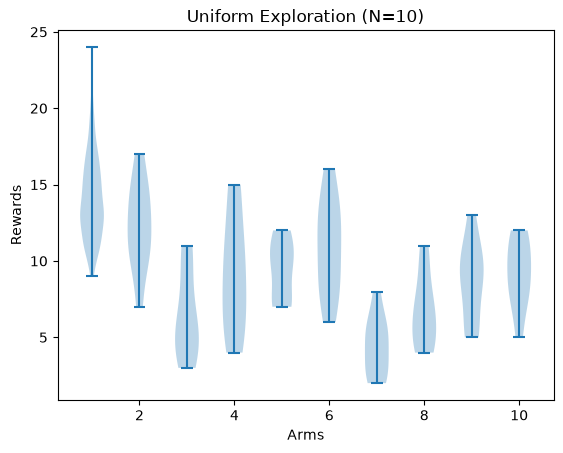

(np.int64(5778), np.int64(0))

In [5]:
K=10
T=500
N = 10

myBandit = Bandit()


def uniform_exploration(myBandit, N, T, plot=False):


    K = myBandit.K

    bandits = [[]]
    for k in range(K):
        bandits.append([]) 

    mean_reward = np.zeros(K)


    # lets explore N time each arm and compute the mean reward for each arm
    for k in range(K):
        for _ in range(N):
            reward = myBandit.get_arm(k)
            bandits[k].append(reward)
        mean_reward[k] = np.mean(bandits[k])


    # select the best arm and pull it for the remaining time
    best_arm = np.argmax(mean_reward)
    print(mean_reward)
    for t in range(N*K, T):
        reward = myBandit.get_arm(best_arm)
        bandits[best_arm].append(reward)
    
    cumulative_reward = np.sum(bandits[best_arm])

    if plot:
        plt.figure()
        plt.violinplot(bandits)
        plt.title(f"Uniform Exploration (N={N})")
        plt.xlabel("Arms")
        plt.ylabel("Rewards")
        plt.show()


    return cumulative_reward, best_arm


uniform_exploration(myBandit, N, T, plot=True)

#  epsilon greedy

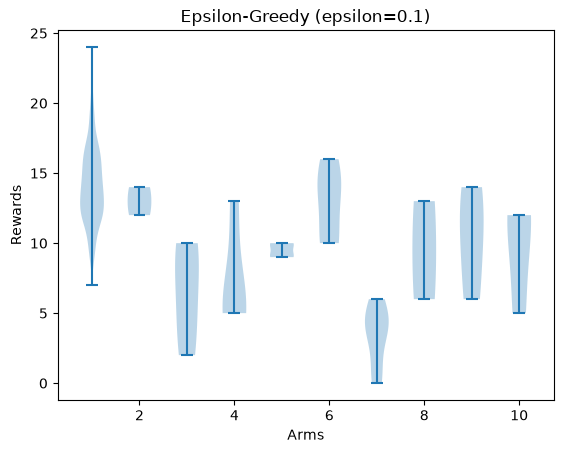

(np.int64(6560), np.int64(0))

In [6]:


def epsilon_greedy(myBandit, N, T, epsilon=0.1, plot=False):
    K = myBandit.K
   
    bandits = [[]]
    for k in range(K):
        bandits.append([]) 

    mean_reward = np.zeros(K)



    Q_a = np.zeros(K)  
    n_a = np.zeros(K)  

    for t in range(T):
        if np.random.rand() < epsilon:
            
            k = np.random.randint(0, K)
        else:
            k = np.argmax(Q_a)

        reward = myBandit.get_arm(k)
        bandits[k].append(reward)

        n_a[k] += 1
        Q_a[k] += (reward - Q_a[k]) / n_a[k]

    best_arm = np.argmax(Q_a)
    cumulative_reward = np.sum(bandits[best_arm])

    if plot:
        plt.figure()
        plt.violinplot(bandits)
        plt.title(f"Epsilon-Greedy (epsilon={epsilon})")
        plt.xlabel("Arms")
        plt.ylabel("Rewards")
        plt.show()

    return cumulative_reward, best_arm



epsilon_greedy(myBandit, N, T, epsilon=0.1, plot=True)

# Successive elimation

In [16]:
K=10
T=500
N = 10

myBandit = Bandit()


def succesive_elimination(myBandit, plot=False):
    K = myBandit.K
    bandits = [[]]
    for k in range(K):
        bandits.append([]) 
    ubc = np.zeros(K) + np.array([myBandit.get_arm(i) for i in range(K)])
    lcb = np.zeros(K) - np.array([myBandit.get_arm(i) for i in range(K)])
    n_t = np.zeros(K)
    active_arms= np.ones(K)

    for t in range(T):
        active_arms_idx= [idx[0] for idx in np.argwhere(active_arms)]
        for idx in active_arms_idx:
            if np.any(ubc[idx] < lcb):
                active_arms[idx] = 0

        for k in active_arms_idx:
            reward = myBandit.get_arm(k)
            bandits[k].append(reward)
            n_t[k] += 1

            ubc[k] = np.mean(bandits[k]) + 2*np.log10(t)/n_t[k]
            lcb[k] = np.mean(bandits[k]) - 2*np.log10(t)/n_t[k]
        
    best_arm = np.argmax(np.sum([bandits[k]] for k in range(K)))

    cumulative_reward = np.sum(bandits[best_arm])

    return cumulative_reward, best_arm  




        

            
        
succesive_elimination(myBandit, plot=False)



    

/tmp/ipykernel_24307/512180664.py:29: RuntimeWarning: divide by zero encountered in log10
  ubc[k] = np.mean(bandits[k]) + 2*np.log10(t)/n_t[k]
/tmp/ipykernel_24307/512180664.py:30: RuntimeWarning: divide by zero encountered in log10
  lcb[k] = np.mean(bandits[k]) - 2*np.log10(t)/n_t[k]


TypeError: Calling np.sum(generator) is deprecated.Use np.sum(np.fromiter(generator)) or the python sum builtin instead.

In [13]:
active_arms= np.zeros(K)
active_arms[0] += 1
active_arms

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])